> **Runtime: Google Colab required** — This notebook needs `tiktoken` and `transformers`, which require native C/Rust extensions unavailable in JupyterLite.
>
> [![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/L3GJ0N/course-notebooks-public/blob/main/02-tokenizer-playground.ipynb)
>
> **[Click here to open in Google Colab](https://colab.research.google.com/github/L3GJ0N/course-notebooks-public/blob/main/02-tokenizer-playground.ipynb)**

# Tokenizer Playground

**Lecture 4 — Tokenization: How Machines Read**

In this notebook you will explore the tokenizers used by real language models. You will see how text is split into tokens, compare tokenizers across models, discover the multilingual gap, and estimate token budgets for your own projects.

## How to Run This Notebook

This notebook uses `tiktoken` and `transformers` — Python packages with native Rust/C backends. These **cannot run in JupyterLite** (the browser-based Jupyter you may be viewing this in). You have two options:

### Option 1: Google Colab (recommended — no setup needed)

Click the link at the top of this notebook to open it in Google Colab. Everything is pre-installed — just run the cells. No Python environment, no HuggingFace account, no local setup required. Colab provides a free GPU-enabled Python runtime in your browser.

### Option 2: Local setup

If you prefer to work locally:
1. Clone the [hf-llm-uv-starter](https://github.com/L3GJ0N/hf-llm-uv-starter) repo or set up your own Python environment
2. Install packages: `pip install tiktoken transformers matplotlib`
3. For loading HuggingFace tokenizers (Section 3): you need a [HuggingFace account](https://huggingface.co/join) and must accept the model licenses (e.g., Meta's LLaMA 3 license)
4. Run this notebook with `jupyter lab` or VS Code

### Why not JupyterLite?

If you opened this notebook from the [Course Notebook Hub](https://l3gj0n.github.io/course-notebooks/lab/), you can read all the text and see the code — but running the cells will fail because `tiktoken` requires a Rust backend that WebAssembly does not support. Use Colab or a local setup instead. (The BPE notebook *does* run in JupyterLite because it uses only pure Python.)

## What You Will Do

1. Tokenize text with tiktoken (GPT-4o's tokenizer)
2. Compare tokenizers across frontier models
3. Measure the multilingual token gap
4. Explore how code gets tokenized
5. Dig into vocabularies — find patterns, glitch tokens, longest tokens
6. Estimate context window budgets for your projects

## 1. Setup

Run the cell below to install and import the required packages.

**HuggingFace authentication (required for LLaMA 3 and Gemma 2):**
Some tokenizers live behind a license gate on HuggingFace. To load them you need to:
1. Create a free account at [huggingface.co/join](https://huggingface.co/join)
2. Accept the model licenses: [Meta LLaMA 3](https://huggingface.co/meta-llama/Meta-Llama-3-8B) and [Google Gemma 2](https://huggingface.co/google/gemma-2-2b)
3. Run the login cell below and paste your [access token](https://huggingface.co/settings/tokens)

If you skip the login or haven't accepted a license, those tokenizers will be skipped automatically — the notebook still works, you'll just compare fewer models.

In [1]:
!pip install -q tiktoken transformers matplotlib

import tiktoken
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [ ]:
# Log in to HuggingFace (needed for LLaMA 3 and Gemma 2 tokenizers).
# Running this cell will prompt you for your access token.
# If you skip this, those two tokenizers will be skipped automatically.
from huggingface_hub import login
login()

## 2. First Contact: How GPT-4o Reads Text

Let's start with OpenAI's tokenizer. GPT-4o uses the `o200k_base` encoding — a byte-level BPE tokenizer with approximately 200,000 tokens in its vocabulary.

We'll write a small helper function that shows us exactly how a tokenizer splits text.

In [2]:
# Load GPT-4o's tokenizer
enc = tiktoken.get_encoding("o200k_base")

def show_tokens(text: str, encoding=enc) -> None:
    """Tokenize text and display each token with its ID."""
    token_ids = encoding.encode(text)
    tokens = [encoding.decode([tid]) for tid in token_ids]

    print(f"Text:       {text!r}")
    print(f"Token IDs:  {token_ids}")
    print(f"Tokens:     {tokens}")
    print(f"Count:      {len(token_ids)} tokens")
    print()

# Try it!
show_tokens("strawberry")

Text:       'strawberry'
Token IDs:  [302, 1618, 19772]
Tokens:     ['st', 'raw', 'berry']
Count:      3 tokens



### Your Turn: The Strawberry Test and Beyond

Tokenize each of the following. For each one, note: how many tokens? Where do the splits fall? Any surprises?

In [3]:
# TODO: Tokenize each of these and observe the splits
words = [
    "strawberry",
    "mississippi",
    "unbreakable",
    # Add your own first name here:
    # "YourName",
    "Hochschule Aalen",
    "Stanford University",
    "def calculate_average(values: list[float]) -> float:",
    'public static double calculateAverage(List<Double> values) {',
]

for word in words:
    show_tokens(word)

Text:       'strawberry'
Token IDs:  [302, 1618, 19772]
Tokens:     ['st', 'raw', 'berry']
Count:      3 tokens

Text:       'mississippi'
Token IDs:  [15399, 43884]
Tokens:     ['miss', 'issippi']
Count:      2 tokens

Text:       'unbreakable'
Token IDs:  [373, 15354, 562]
Tokens:     ['un', 'break', 'able']
Count:      3 tokens

Text:       'Hochschule Aalen'
Token IDs:  [39, 6988, 80090, 355, 14260]
Tokens:     ['H', 'och', 'schule', ' A', 'alen']
Count:      5 tokens

Text:       'Stanford University'
Token IDs:  [93447, 9201, 4923]
Tokens:     ['Stan', 'ford', ' University']
Count:      3 tokens

Text:       'def calculate_average(values: list[float]) -> float:'
Token IDs:  [1314, 17950, 89222, 40883, 25, 1562, 58, 7829, 4636, 2747, 4428, 25]
Tokens:     ['def', ' calculate', '_average', '(values', ':', ' list', '[', 'float', '])', ' ->', ' float', ':']
Count:      12 tokens

Text:       'public static double calculateAverage(List<Double> values) {'
Token IDs:  [1154, 1633, 3503,

**Questions to answer:**
- How many tokens does `Hochschule Aalen` take compared to `Stanford University`? Why?
- Does `unbreakable` split into `un` + `break` + `able`? Or something different?
- Compare the Python and Java function signatures — which uses more tokens? Why might that matter for code generation?

## 3. Compare Tokenizers Across Models

Different models use different tokenizers — trained on different data, with different vocabulary sizes. Let's load several and compare them side by side.

| Model | Tokenizer | Vocab Size | Library |
|-------|-----------|------------|---------|
| GPT-4o | o200k_base | ~200K | tiktoken |
| GPT-4 | cl100k_base | ~100K | tiktoken |
| LLaMA 3 | BPE | 128K | HuggingFace |
| Gemma 2 | SentencePiece | 256K | HuggingFace |

In [5]:
# Load multiple tokenizers
# tiktoken tokenizers always work; HuggingFace ones need authentication + license acceptance.
# If a model fails to load it is skipped — the rest of the notebook still works.

tokenizers = {}

# --- tiktoken (always available) ---
tokenizers["GPT-4o"] = ("tiktoken", tiktoken.get_encoding("o200k_base"))
tokenizers["GPT-4"]  = ("tiktoken", tiktoken.get_encoding("cl100k_base"))

# --- HuggingFace (may require login + license) ---
_hf_models = {
    "LLaMA 3": "meta-llama/Meta-Llama-3-8B",
    "Gemma 2":  "google/gemma-2-2b",
}

for name, model_id in _hf_models.items():
    try:
        tokenizers[name] = ("hf", AutoTokenizer.from_pretrained(model_id))
        print(f"  ✓ {name} loaded")
    except Exception as e:
        print(f"  ✗ {name} skipped ({type(e).__name__}: {e})")

print(f"\nLoaded {len(tokenizers)} tokenizer(s): {', '.join(tokenizers.keys())}")
if len(tokenizers) < 4:
    print("Tip: to load all 4, run the HuggingFace login cell above and accept the model licenses.")

def count_tokens(text: str, kind: str, tok) -> int:
    """Count tokens for a given text using the specified tokenizer."""
    if kind == "tiktoken":
        return len(tok.encode(text))
    else:  # HuggingFace
        return len(tok.encode(text))

def compare_tokenizers(text: str) -> None:
    """Show token counts across all loaded tokenizers."""
    print(f"Text: {text!r}")
    print("-" * 50)
    for name, (kind, tok) in tokenizers.items():
        n = count_tokens(text, kind, tok)
        print(f"  {name:12s}: {n:4d} tokens")
    print()

  ✗ LLaMA 3 skipped (OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3-8B.
401 Client Error. (Request ID: Root=1-69dcc811-1e8c2a580ef1793a331f24de;718039cb-2d38-4961-b589-78a273b4b781)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3-8B/resolve/main/config.json.
Access to model meta-llama/Meta-Llama-3-8B is restricted. You must have access to it and be authenticated to access it. Please log in.)
  ✗ Gemma 2 skipped (OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2-2b.
401 Client Error. (Request ID: Root=1-69dcc811-5345656628e4cfda43081edc;32c6eb4f-931c-40f6-b895-cb39f79456c7)

Cannot access gated repo for url https://huggingface.co/google/gemma-2-2b/resolve/main/config.json.
Access to model google/gemma-2-2b is restricted. You must have access to it and be authenticated to access it. Please log in.)

Loaded

In [ ]:
# Compare on several test strings
test_strings = [
    "Hello, world!",
    "def calculate_average(values: list[float]) -> float:",
    "Künstliche Intelligenz verändert die Softwareentwicklung.",
    "The quick brown fox jumps over the lazy dog.",
    "1234 + 5678 = 6912",
]

for text in test_strings:
    compare_tokenizers(text)

**Questions to answer:**
- Which tokenizer produces the fewest tokens overall? Why might that be?
- Do all tokenizers split the German sentence the same way?
- Do you see any case where a larger vocabulary actually produces *more* tokens?

## 4. The Multilingual Gap

In Lecture 4 (Chapter 17) we learned that non-English text costs more tokens. Let's measure this precisely.

**Task:** Tokenize the same sentence in English and German (and optionally a third language). Calculate the token ratio.

In [8]:
sentences = {
    "English": "Artificial intelligence is changing software development.",
    "German":  "Künstliche Intelligenz verändert die Softwareentwicklung.",
    # TODO: Add a third language if you speak one
    # "Spanish": "La inteligencia artificial está cambiando el desarrollo de software.",
    # "Chinese": "人工智能正在改变软件开发。",
}

# Count tokens per language for each tokenizer
results = {}
for lang, text in sentences.items():
    results[lang] = {}
    for name, (kind, tok) in tokenizers.items():
        results[lang][name] = count_tokens(text, kind, tok)

# Display as a table
print(f"{'Language':12s}", end="")
for name in tokenizers:
    print(f"  {name:>10s}", end="")
print()
print("-" * (12 + 12 * len(tokenizers)))
for lang, counts in results.items():
    print(f"{lang:12s}", end="")
    for name in tokenizers:
        print(f"  {counts[name]:>10d}", end="")
    print()

# Calculate ratios relative to English
print("\nRatio (relative to English):")
for lang, counts in results.items():
    if lang == "English":
        continue
    print(f"  {lang}:", end="")
    for name in tokenizers:
        ratio = counts[name] / results["English"][name]
        print(f"  {name}: {ratio:.2f}x", end="")
    print()

Language          GPT-4o       GPT-4
------------------------------------
English                7           8
German                11          15

Ratio (relative to English):
  German:  GPT-4o: 1.57x  GPT-4: 1.88x


### Visualize the Gap

Let's make a bar chart to see the multilingual token cost at a glance.

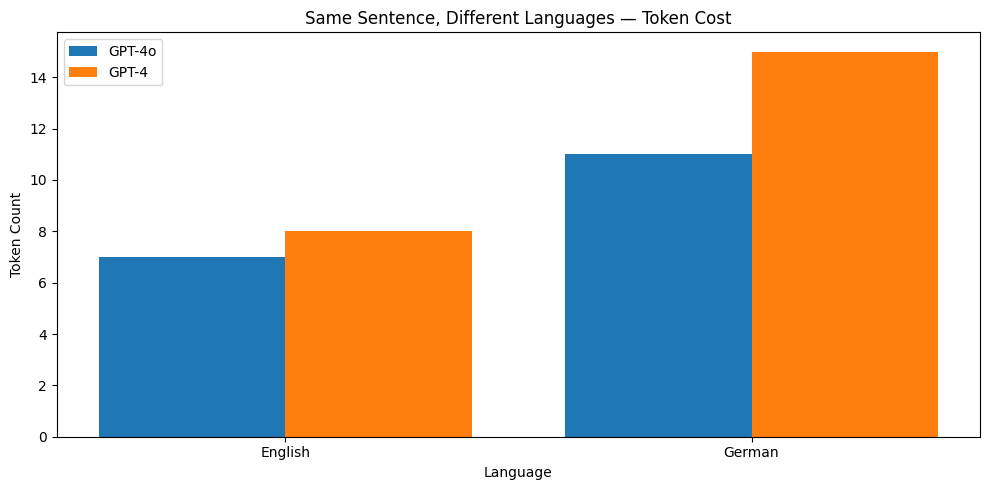

In [9]:
# Bar chart: token counts per language, grouped by tokenizer
fig, ax = plt.subplots(figsize=(10, 5))

languages = list(results.keys())
tok_names = list(tokenizers.keys())
x = range(len(languages))
width = 0.8 / len(tok_names)

for i, name in enumerate(tok_names):
    counts = [results[lang][name] for lang in languages]
    offset = (i - len(tok_names) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], counts, width, label=name)

ax.set_xlabel("Language")
ax.set_ylabel("Token Count")
ax.set_title("Same Sentence, Different Languages — Token Cost")
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.legend()
plt.tight_layout()
plt.show()

## 5. The Arithmetic Breakdown

In Chapter 7 we saw that models struggle with arithmetic. The root cause: digits get split inconsistently across token boundaries. Let's see this directly.

In [10]:
# Tokenize numbers and see where the boundaries fall
numbers = ["999", "1000", "1001", "1234", "5678", "2249", "2250", "2251"]

print("How GPT-4o tokenizes numbers:")
print("-" * 50)
for num in numbers:
    token_ids = enc.encode(num)
    tokens = [enc.decode([tid]) for tid in token_ids]
    print(f"  {num:>6s}  →  {tokens}  ({len(tokens)} token{'s' if len(tokens) > 1 else ''})")

print()
print("Notice: three consecutive numbers (2249, 2250, 2251)")
print("get completely different internal representations!")
print()

# Now tokenize an arithmetic expression
show_tokens("1234 + 5678")
show_tokens("3.14159")

How GPT-4o tokenizes numbers:
--------------------------------------------------
     999  →  ['999']  (1 token)
    1000  →  ['100', '0']  (2 tokens)
    1001  →  ['100', '1']  (2 tokens)
    1234  →  ['123', '4']  (2 tokens)
    5678  →  ['567', '8']  (2 tokens)
    2249  →  ['224', '9']  (2 tokens)
    2250  →  ['225', '0']  (2 tokens)
    2251  →  ['225', '1']  (2 tokens)

Notice: three consecutive numbers (2249, 2250, 2251)
get completely different internal representations!

Text:       '1234 + 5678'
Token IDs:  [7633, 19, 659, 220, 34904, 23]
Tokens:     ['123', '4', ' +', ' ', '567', '8']
Count:      6 tokens

Text:       '3.14159'
Token IDs:  [18, 13, 16926, 4621]
Tokens:     ['3', '.', '141', '59']
Count:      4 tokens



**Questions to answer:**
- Can you see why 1234 + 5678 would be hard for a model? Where do the place-value columns fall relative to token boundaries?
- Do ALL tokenizers split these numbers the same way? Try with the other tokenizers from Section 3.

## 6. How Code Gets Tokenized

This is a course about AI-supported **software development**. Code has its own tokenization properties that directly affect how well Copilot, Claude Code, and other AI tools work. Let's explore them.

In Lecture 4 (Chapter 19), we discuss five code-specific tokenization phenomena: indentation cost, naming conventions, boilerplate efficiency, programming language differences, and comments as context. Here you will verify each one empirically.

In [11]:
# --- Experiment 1: Indentation cost ---
# Same logic, different nesting depth

flat_code = """def process(items):
    results = []
    for item in items:
        if item.is_valid():
            results.append(item.value)
    return results"""

nested_code = """def process(data):
    results = []
    for category in data:
        for group in category.groups:
            for item in group.items:
                if item.is_valid():
                    if item.value > 0:
                        results.append(item.value)
    return results"""

print("=== Indentation Cost ===")
show_tokens(flat_code)
show_tokens(nested_code)
print(f"Flat code:   {len(enc.encode(flat_code)):3d} tokens")
print(f"Nested code: {len(enc.encode(nested_code)):3d} tokens")
print(f"Difference:  {len(enc.encode(nested_code)) - len(enc.encode(flat_code)):+3d} tokens (deeper nesting costs more)")

=== Indentation Cost ===
Text:       'def process(items):\n    results = []\n    for item in items:\n        if item.is_valid():\n            results.append(item.value)\n    return results'
Token IDs:  [1314, 2273, 50514, 1883, 271, 4376, 314, 8911, 271, 395, 2169, 306, 4732, 734, 309, 538, 2169, 3109, 23321, 8595, 352, 4376, 3709, 10016, 4683, 446, 271, 622, 4376]
Tokens:     ['def', ' process', '(items', '):\n', '   ', ' results', ' =', ' []\n', '   ', ' for', ' item', ' in', ' items', ':\n', '       ', ' if', ' item', '.is', '_valid', '():\n', '           ', ' results', '.append', '(item', '.value', ')\n', '   ', ' return', ' results']
Count:      29 tokens

Text:       'def process(data):\n    results = []\n    for category in data:\n        for group in category.groups:\n            for item in group.items:\n                if item.is_valid():\n                    if item.value > 0:\n                        results.append(item.value)\n    return results'
Token IDs:  [1314, 2273, 4

In [12]:
# --- Experiment 2: Naming conventions ---
# Same identifier, different styles

identifiers = {
    "camelCase":    "calculateAverageScore",
    "snake_case":   "calculate_average_score",
    "PascalCase":   "CalculateAverageScore",
    "SCREAMING":    "CALCULATE_AVERAGE_SCORE",
    "short":        "calc_avg",
    "single_char":  "x",
}

print("=== Naming Convention Token Cost ===")
print(f"{'Style':15s}  {'Identifier':30s}  {'Tokens':>6s}")
print("-" * 55)
for style, name in identifiers.items():
    n = len(enc.encode(name))
    tokens = [enc.decode([t]) for t in enc.encode(name)]
    print(f"{style:15s}  {name:30s}  {n:>6d}  → {tokens}")

=== Naming Convention Token Cost ===
Style            Identifier                      Tokens
-------------------------------------------------------
camelCase        calculateAverageScore                3  → ['calculate', 'Average', 'Score']
snake_case       calculate_average_score              3  → ['calculate', '_average', '_score']
PascalCase       CalculateAverageScore                3  → ['Calculate', 'Average', 'Score']
SCREAMING        CALCULATE_AVERAGE_SCORE              7  → ['CAL', 'CUL', 'ATE', '_AV', 'ER', 'AGE', '_SCORE']
short            calc_avg                             2  → ['calc', '_avg']
single_char      x                                    1  → ['x']


In [14]:
# --- Experiment 3: Boilerplate vs novel code ---

boilerplate_snippets = [
    ("__init__",       "def __init__(self):"),
    ("__str__",        "def __str__(self):"),
    ("import",         "from collections import defaultdict"),
    ("main guard",     'if __name__ == "__main__":'),
]

novel_snippets = [
    ("domain func",    "def calibrate_magnetometer(readings: list[SensorDatum]):"),
    ("custom class",   "class QuantumStateEstimator(BaseEstimator):"),
    ("domain import",  "from neuromorphic_simulator.core import SpikeTrainAnalyzer"),
    ("business rule",  'if customer.loyalty_tier == "PLATINUM" and order.subtotal > 500:'),
]

print("=== Boilerplate vs Novel Code ===")
print(f"\n{'Type':15s}  {'Label':15s}  {'Tokens':>6s}  Code")
print("-" * 80)
for label, code in boilerplate_snippets:
    n = len(enc.encode(code))
    print(f"{'Boilerplate':15s}  {label:15s}  {n:>6d}  {code}")
for label, code in novel_snippets:
    n = len(enc.encode(code))
    print(f"{'Novel':15s}  {label:15s}  {n:>6d}  {code}")

=== Boilerplate vs Novel Code ===

Type             Label            Tokens  Code
--------------------------------------------------------------------------------
Boilerplate      __init__              6  def __init__(self):
Boilerplate      __str__               6  def __str__(self):
Boilerplate      import                4  from collections import defaultdict
Boilerplate      main guard            9  if __name__ == "__main__":
Novel            domain func          14  def calibrate_magnetometer(readings: list[SensorDatum]):
Novel            custom class          7  class QuantumStateEstimator(BaseEstimator):
Novel            domain import        11  from neuromorphic_simulator.core import SpikeTrainAnalyzer
Novel            business rule        22  if customer.loyalty_tier == "PLATINUM" and order.subtotal > 500:


In [15]:
# --- Experiment 4: Same algorithm, different programming languages ---

python_code = '''def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)'''

java_code = '''public static int fibonacci(int n) {
    if (n <= 1) {
        return n;
    }
    return fibonacci(n - 1) + fibonacci(n - 2);
}'''

rust_code = '''fn fibonacci(n: u32) -> u32 {
    if n <= 1 {
        return n;
    }
    fibonacci(n - 1) + fibonacci(n - 2)
}'''

print("=== Same Algorithm, Different Languages ===")
for lang, code in [("Python", python_code), ("Java", java_code), ("Rust", rust_code)]:
    n = len(enc.encode(code))
    chars = len(code)
    print(f"  {lang:8s}: {n:3d} tokens, {chars:3d} chars, ratio: {chars/n:.1f} chars/token")

=== Same Algorithm, Different Languages ===
  Python  :  30 tokens,  96 chars, ratio: 3.2 chars/token
  Java    :  39 tokens, 128 chars, ratio: 3.3 chars/token
  Rust    :  39 tokens, 111 chars, ratio: 2.8 chars/token


In [16]:
# --- Experiment 5: Comments as context cost ---

code_no_comments = '''def validate_email(address):
    pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(pattern, address))'''

code_with_comments = '''def validate_email(address):
    # RFC 5322 compliant email validation
    # Checks: local part (alphanumeric + special chars), @ symbol,
    # domain (alphanumeric + hyphens), TLD (2+ letters)
    pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(pattern, address))'''

n_no = len(enc.encode(code_no_comments))
n_with = len(enc.encode(code_with_comments))

print("=== Comments as Context Cost ===")
print(f"  Without comments: {n_no:3d} tokens")
print(f"  With comments:    {n_with:3d} tokens")
print(f"  Comment cost:     {n_with - n_no:+3d} tokens ({(n_with - n_no) / n_no * 100:.0f}% overhead)")
print(f"\n  Those {n_with - n_no} extra tokens tell the model WHY this code exists.")
print(f"  Is that worth it? Depends on the task.")

=== Comments as Context Cost ===
  Without comments:  51 tokens
  With comments:     95 tokens
  Comment cost:     +44 tokens (86% overhead)

  Those 44 extra tokens tell the model WHY this code exists.
  Is that worth it? Depends on the task.


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_21419/2585875816.py:4: SyntaxWarning: invalid escape sequence '\.'
  pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
/tmp/ipykernel_21419/2585875816.py:11: SyntaxWarning: invalid escape sequence '\.'
  pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'


**Questions to answer:**
- Which naming convention is most token-efficient? Does that surprise you?
 : Snake_case (or simply lowercase without delimiters) is generally the most token-efficient naming convention for Large Language Models (LLMs), particularly when working with Python and many modern codebases.
- How many extra tokens does deep nesting cost? What would you do to reduce it?
- Java vs Python: how much more "context budget" does the model have when generating Python?
- When are comments worth their token cost? When are they wasteful?
- If you were writing a CLAUDE.md rule about code style, what would you recommend based on these findings?

## 7. Vocabulary Archaeology

Every tokenizer has a vocabulary — a fixed list of tokens it knows. Let's dig into GPT-4o's vocabulary and see what's inside.

In [17]:
# How big is the vocabulary?
print(f"GPT-4o vocabulary size: {enc.n_vocab:,} tokens")

# Decode the first 200 tokens — what do they look like?
print("\nFirst 200 tokens in the vocabulary:")
print("-" * 60)
for i in range(200):
    try:
        token_str = enc.decode([i])
        print(f"  {i:5d}: {token_str!r}")
    except Exception:
        print(f"  {i:5d}: [cannot decode]")

GPT-4o vocabulary size: 200,019 tokens

First 200 tokens in the vocabulary:
------------------------------------------------------------
      0: '!'
      1: '"'
      2: '#'
      3: '$'
      4: '%'
      5: '&'
      6: "'"
      7: '('
      8: ')'
      9: '*'
     10: '+'
     11: ','
     12: '-'
     13: '.'
     14: '/'
     15: '0'
     16: '1'
     17: '2'
     18: '3'
     19: '4'
     20: '5'
     21: '6'
     22: '7'
     23: '8'
     24: '9'
     25: ':'
     26: ';'
     27: '<'
     28: '='
     29: '>'
     30: '?'
     31: '@'
     32: 'A'
     33: 'B'
     34: 'C'
     35: 'D'
     36: 'E'
     37: 'F'
     38: 'G'
     39: 'H'
     40: 'I'
     41: 'J'
     42: 'K'
     43: 'L'
     44: 'M'
     45: 'N'
     46: 'O'
     47: 'P'
     48: 'Q'
     49: 'R'
     50: 'S'
     51: 'T'
     52: 'U'
     53: 'V'
     54: 'W'
     55: 'X'
     56: 'Y'
     57: 'Z'
     58: '['
     59: '\\'
     60: ']'
     61: '^'
     62: '_'
     63: '`'
     64: 'a'
     65: 'b'
    

### Find the Longest Token

What is the longest single token in the vocabulary? This tells you about the most common phrases in the training data.

In [18]:
# TODO: Find the longest token in the vocabulary
# Hint: decode each token ID, measure its length, track the maximum
#
# Strategy: iterate over a range of token IDs, decode each one,
# and keep track of the longest decoded string.
# Note: some token IDs may fail to decode — wrap in try/except.

longest_token = ""
longest_id = -1

for i in range(enc.n_vocab):
    try:
        token_str = enc.decode([i])
        if len(token_str) > len(longest_token):
            longest_token = token_str
            longest_id = i
    except Exception:
        continue

print(f"Longest token: ID {longest_id}")
print(f"Content: {longest_token!r}")
print(f"Length: {len(longest_token)} characters")

Longest token: ID 72056
Content: '                                                                                                                                '
Length: 128 characters


### Glitch Token Exploration

In Chapter 18 of the lecture, we discussed glitch tokens — tokens that exist in the vocabulary but cause the model to malfunction because they were never properly trained. Let's check if some famous ones still exist.

In [19]:
# Check famous glitch tokens — do they tokenize as single tokens?
glitch_candidates = [
    " SolidGoldMagikarp",  # note the leading space
    " TheNitromeFan",
    "SolidGoldMagikarp",   # without leading space
]

print("Glitch token check (GPT-4o / o200k_base):")
print("-" * 50)
for text in glitch_candidates:
    token_ids = enc.encode(text)
    tokens = [enc.decode([tid]) for tid in token_ids]
    is_single = len(token_ids) == 1
    status = "SINGLE TOKEN (potential glitch!)" if is_single else f"split into {len(token_ids)} tokens"
    print(f"  {text!r:30s} → {status}")
    print(f"    Tokens: {tokens}")
    print()

# Also check with the older GPT-4 tokenizer (cl100k_base)
enc_old = tiktoken.get_encoding("cl100k_base")
print("Same check with GPT-4 / cl100k_base:")
print("-" * 50)
for text in glitch_candidates:
    token_ids = enc_old.encode(text)
    tokens = [enc_old.decode([tid]) for tid in token_ids]
    is_single = len(token_ids) == 1
    status = "SINGLE TOKEN" if is_single else f"split into {len(token_ids)} tokens"
    print(f"  {text!r:30s} → {status}")

Glitch token check (GPT-4o / o200k_base):
--------------------------------------------------
  ' SolidGoldMagikarp'           → split into 5 tokens
    Tokens: [' Solid', 'Gold', 'Mag', 'ik', 'arp']

  ' TheNitromeFan'               → split into 4 tokens
    Tokens: [' The', 'Nit', 'rome', 'Fan']

  'SolidGoldMagikarp'            → split into 5 tokens
    Tokens: ['Solid', 'Gold', 'Mag', 'ik', 'arp']

Same check with GPT-4 / cl100k_base:
--------------------------------------------------
  ' SolidGoldMagikarp'           → split into 5 tokens
  ' TheNitromeFan'               → split into 4 tokens
  'SolidGoldMagikarp'            → split into 5 tokens


## 8. Token Budget Estimation

Everything in the context window costs tokens — your prompt, CLAUDE.md, the model's response, tool results. Let's calculate a real budget.

**Task:** Tokenize your CLAUDE.md from the Locust exercise (Lecture 3) and estimate how much of the context window it consumes.

In [20]:
# TODO: Paste your CLAUDE.md content here (or load from file)
claude_md = """
# Your CLAUDE.md content here
# Paste the content from your Locust exercise
"""

# Tokenize it
claude_md_tokens = len(enc.encode(claude_md))
print(f"Your CLAUDE.md: {claude_md_tokens:,} tokens")

# Context budget calculation
context_window = 200_000  # Claude's context window
system_prompt_estimate = 3_000  # approximate system prompt size
typical_prompt = 200  # a typical user prompt

remaining = context_window - system_prompt_estimate - claude_md_tokens - typical_prompt

print(f"\n--- Context Budget (Claude, 200K window) ---")
print(f"  Context window:    {context_window:>10,} tokens")
print(f"  System prompt:    -{system_prompt_estimate:>10,} tokens (estimate)")
print(f"  Your CLAUDE.md:   -{claude_md_tokens:>10,} tokens")
print(f"  Typical prompt:   -{typical_prompt:>10,} tokens")
print(f"                    {'─' * 20}")
print(f"  Remaining:         {remaining:>10,} tokens ({remaining/context_window*100:.1f}%)")
print()

# What if CLAUDE.md grew?
for size_label, size in [("1,000 tokens", 1000), ("5,000 tokens", 5000), ("10,000 tokens", 10000)]:
    rem = context_window - system_prompt_estimate - size - typical_prompt
    print(f"  If CLAUDE.md = {size_label}: {rem:,} remaining ({rem/context_window*100:.1f}%)")

Your CLAUDE.md: 20 tokens

--- Context Budget (Claude, 200K window) ---
  Context window:       200,000 tokens
  System prompt:    -     3,000 tokens (estimate)
  Your CLAUDE.md:   -        20 tokens
  Typical prompt:   -       200 tokens
                    ────────────────────
  Remaining:            196,780 tokens (98.4%)

  If CLAUDE.md = 1,000 tokens: 195,800 remaining (97.9%)
  If CLAUDE.md = 5,000 tokens: 191,800 remaining (95.9%)
  If CLAUDE.md = 10,000 tokens: 186,800 remaining (93.4%)


## 9. Your Findings

Write your answers directly in the cells below. Double-click a cell to edit it. If you are working in JupyterLite, your answers are saved in your browser. If you are in Colab, use File → Save a copy or File → Download to keep your work.

---

### 1. Five surprising tokenization results

List at least 5 results from this notebook that surprised you. For each one, explain *why* it happens based on what you learned in the lecture.

*Your answer here*

### 2. The multilingual gap — your numbers

What was the English-to-German token ratio you measured? Which tokenizer handled German best? If you were building a model for a German-speaking audience, what would you change about the tokenizer?

*Your answer here*

### 3. Your CLAUDE.md token budget

How many tokens did your CLAUDE.md consume? What percentage of the 200K context window is that? How does knowing this change how you would write CLAUDE.md files in the future?

*Your answer here*

### 4. One thing you would change about your prompting

Based on what you now understand about tokenization, what is one concrete thing you would do differently when prompting an AI coding tool?

*Your answer here*

### 5. Code style recommendation

Based on your code tokenization experiments (Section 6): should you optimize your code for token efficiency? When does it matter, when doesn't it? If you were writing a CLAUDE.md rule about code style for AI tools, what would it say?

*Your answer here*